<a href="https://colab.research.google.com/github/olchan/BigContest-2022/blob/main/Model_Prediction_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 라이브러리 호출

In [ ]:
import os
import random
import time
import pandas as pd
import numpy as np
import datetime

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.init as init
from torch.utils.data import Dataset, DataLoader, TensorDataset

#최적화 라이브러리
import optuna

#metrics
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

#scaling
from sklearn.preprocessing import StandardScaler

#pandas option
pd.set_option('display.max_columns', None)

#시각화 라이브러리
import matplotlib.pyplot as plt
import seaborn as sns

#불필요한 경고 제거
import warnings
warnings.filterwarnings("ignore")

# 코드 파일이 "~~~/빅콘"에 있도록 수정
path = '/home/user/Code/JE/빅콘/data/'

In [ ]:
log_data = pd.read_csv(path + "log_data.csv")
user_spec = pd.read_csv(path + "user_spec.csv")
loan_result = pd.read_csv(path + "loan_result.csv")

loan_result["loanapply_insert_time"]=pd.to_datetime(loan_result["loanapply_insert_time"])
loan_result.sort_values(["application_id","loanapply_insert_time"],inplace = True)
user_spec["insert_time"] = pd.to_datetime(user_spec["insert_time"])
user_spec.sort_values("application_id", inplace = True)

### **1. Preprocessing**

In [ ]:
# 신청서를 신청한 사람들만 모여있는 user_spec
# user_spec에 있는 신청서만 들어있는 loan_result로 업데이트

set1 = set(loan_result["application_id"].unique())
set2 = set(user_spec["application_id"].unique())
target_set = set1.intersection(set2)

user_spec = user_spec[user_spec["application_id"].isin(target_set)]
loan_result = loan_result[loan_result["application_id"].isin(target_set)]

In [ ]:
def separate_user(user_spec):
  # user에 따라 변함이 없는 정보의 싱크를 맞추기 위해 user_id 기준으로 groupby
    user_spec = user_spec.copy()
    user = user_spec.loc[:, ["user_id", "birth_year", "gender", "existing_loan_cnt", "existing_loan_amt"]].copy()
    spec = user_spec.drop(["birth_year", "gender", "existing_loan_cnt", "existing_loan_amt"], axis = 1)
    user = user.groupby("user_id").min()

    # existing_loan_cnt의 결측치는 0으로 대체, existing_loan_cnt가 0이면 amt도 0으로 대체
    user["existing_loan_cnt"] = user["existing_loan_cnt"].fillna(0)
    user["existing_loan_amt"] = np.where(user["existing_loan_cnt"] == 0, 0, user["existing_loan_amt"])

    # birth_year, gender는 각각 중간값, 최빈값으로 대체
    user["birth_year"] = user["birth_year"].fillna(user["birth_year"].median())
    user["gender"] = user["gender"].fillna(1)

    # existing_loan_amt 로그 변환
    user["existing_loan_amt"] = np.log10(user["existing_loan_amt"] + 1)

    # existing_loan_cnt를 기준으로 그룹화한 후, 그룹별 existing_loan_amt의 평균으로 대체
    user["existing_loan_amt"] = user.groupby("existing_loan_cnt")["existing_loan_amt"].transform(lambda x : x.fillna(x.mean()))

    # log_data의 SignUp 이벤트를 사용한 신규 유저(3월 이후 유저) 구분 IsNewApply 변수 추가
    new_user_set = set(log_data[log_data["event"] == "SignUp"]["user_id"].values)
    user = user.reset_index(drop = False)
    user["IsNewApply"] = np.where(user["user_id"].isin(new_user_set) , 1, 0)

    return pd.merge(spec, user)

filled_user_spec = separate_user(user_spec)

In [ ]:
# 네이버랩 "대출" 키워드 빈도수
# 출처: https://datalab.naver.com/keyword/trendResult.naver?hashKey=N_0d526da0abb69e40b4f85def2ecaa68b

trend = pd.read_excel(path + "datalab.xlsx")
trend = trend.drop(np.arange(0, 6), axis = 0)
trend.columns = ["insert_time", "trend"]
trend["insert_time"] = pd.to_datetime(trend["insert_time"])
trend

,insert_time,trend
6,2022-03-01,45.71605
7,2022-03-02,71.46613
8,2022-03-03,63.54778
9,2022-03-04,57.65542
10,2022-03-05,34.51902
...,...,...
123,2022-06-26,38.57098
124,2022-06-27,80.38973
125,2022-06-28,73.21373
126,2022-06-29,69.81132


In [ ]:
def preprocess_user(user_spec):
    user_spec = user_spec.copy()

    # 한글 범주 영어로 변환
    user_spec["employment_type"] = user_spec["employment_type"].replace(
      {'기타': 'EMPLOYMENT_ETC', '정규직': 'PERMANENT', '계약직': 'CONTRACT', '일용직': 'DAYJOB'}
    )
    user_spec["houseown_type"] = user_spec["houseown_type"].replace(
      {'자가': 'OWNHOUSE', '기타가족소유': 'FAMILYHOUSE', '전월세': 'RENT', '배우자': 'SPOUSE'}
    )
    user_spec["purpose"] = user_spec["purpose"].replace(
      {'기타': 'ETC', '대환대출': 'SWITCHLOAN', '생활비': 'LIVING', '사업자금': 'BUSINESS', '자동차구입': 'BUYCAR', '전월세보증금': 'HOUSEDEPOSIT', '투자': 'INVEST', '주택구입': 'BUYHOUSE'}
    )

    # insert_time을 기준으로 요일 변수 day_of_week 추가
    user_spec["day_of_week"] = user_spec["insert_time"].dt.day_name()

    # 상관없는 변수 제거
    user_spec = user_spec.drop(["company_enter_month", "personal_rehabilitation_yn", "personal_rehabilitation_complete_yn"], axis = 1)

    # 결측치와 반올림 에러 50만으로 대체
    user_spec["yearly_income"] = user_spec["yearly_income"].fillna(500000)
    user_spec["yearly_income"] = np.where(user_spec["yearly_income"] == 0, 500000, user_spec["yearly_income"])
    user_spec["desired_amount"] = user_spec["desired_amount"].replace(0, 500000)

    # yearly_income, desired_amount 로그 변환
    user_spec["yearly_income"] = np.log10(user_spec["yearly_income"])
    user_spec["desired_amount"] = np.log10(user_spec["desired_amount"])

    # 외부 데이터의 insert_time과 매칭을 위해 user_spec의 insert_time을 가공
    user_spec["insert_time"] = pd.to_datetime(user_spec["insert_time"].dt.date)
    user_spec = user_spec.merge(trend)

    return user_spec

modified_user_spec = preprocess_user(filled_user_spec)

In [ ]:
def preprocess_loan(loan):
    loan = loan.copy()

    # 반올림 에러 50만으로 대체
    loan["loan_limit"] = np.where(loan["loan_limit"] == 0, 500000, loan["loan_limit"])

    # 지원서를 기준으로 loan_limit, loan_rate를 정렬해서 순위를 매긴 변수
    loan["loan_limit_order"] = loan.groupby("application_id")["loan_limit"].transform(lambda x: x.rank(method = "min", ascending = False))
    loan["loan_rate_order"] = loan.groupby("application_id")["loan_rate"].transform(lambda x: x.rank(method = "min", ascending = True))

    # loan_limit 로그 변환
    loan["loan_limit"] = np.log10(loan["loan_limit"])

    # 필요없는 변수 제거
    loan = loan.drop("loanapply_insert_time", axis = 1)
    return loan

modified_loan_result = preprocess_loan(loan_result)

In [ ]:
# user_spec과 loan_result를 application_id를 기준으로 merge
merge_all = pd.merge(modified_user_spec, modified_loan_result)

In [ ]:
merge_all['trend'] = merge_all['trend'].astype('float')

In [ ]:
# Train: 3~4월, Validation: 5월, Test: 6월
train = merge_all[merge_all["insert_time"] < datetime.datetime(2022, 5, 1)]
validation = merge_all[(merge_all["insert_time"] >= datetime.datetime(2022, 5, 1)) & (merge_all["insert_time"] <= datetime.datetime(2022, 5, 31))]
test = merge_all[merge_all["insert_time"] >= datetime.datetime(2022, 6, 1)]

In [ ]:
# credit_score 전처리를 위한 데이터셋 준비
train_all = train.loc[: ,['trend', 'yearly_income','existing_loan_cnt','existing_loan_amt','credit_score']].dropna(axis = 0)
val_all = validation.loc[: ,['trend', 'yearly_income','existing_loan_cnt','existing_loan_amt','credit_score']].dropna(axis = 0)

train_all = train_all[~train_all.duplicated()]
val_all = val_all[~val_all.duplicated()]

In [ ]:
X_train = train_all.drop("credit_score", axis = 1)
Y_train = train_all["credit_score"]
X_val = val_all.drop("credit_score", axis = 1)
Y_val = val_all["credit_score"]

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import lightgbm
import time

def model_perf(model, X, Y, prefix=''):
    Yhat = model.predict(X)
    score = mean_absolute_error(Y, Yhat)
    print (f'{prefix} score = {score:.5f}')

def model_fit_perf(model, X_train, X_val, Y_train, Y_val, prefix=''):
    start = time.time()
    model.fit(X_train, Y_train)
    finish = time.time() - start
    print (prefix)
    print (f"  Time elasped: {finish:.4f}")
    model_perf(model, X_train, Y_train, '  Training  ')
    model_perf(model, X_val, Y_val, '  Validation')


lgbm = lightgbm.LGBMRegressor(verbose = -1, random_state = 42, max_depth = 20, n_estimators = 4000)
model_fit_perf(lgbm, X_train, X_val, Y_train, Y_val, prefix='LightGBM')

LightGBM
  Time elasped: 12.7738
  Training   score = 70.60662
  Validation score = 77.84024


In [ ]:
train_for_pred = train[train["credit_score"].isnull()].loc[:, ['trend', 'yearly_income','existing_loan_cnt','existing_loan_amt']]
val_for_pred = validation[validation["credit_score"].isnull()].loc[:, ['trend', 'yearly_income','existing_loan_cnt','existing_loan_amt']]
test_for_pred = test[test["credit_score"].isnull()].loc[:, ['trend', 'yearly_income','existing_loan_cnt','existing_loan_amt']]

train.loc[train_for_pred.index, "credit_score"] = lgbm.predict(train_for_pred)
validation.loc[val_for_pred.index, "credit_score"] = lgbm.predict(val_for_pred)
test.loc[test_for_pred.index, "credit_score"] = lgbm.predict(test_for_pred)

In [ ]:
train.to_csv(path + "train.csv", index = False)
validation.to_csv(path + "val.csv", index = False)
test.to_csv(path + "test.csv", index = False)

In [ ]:
# 클러스터링을 위한 데이터셋
train_clustering = train.loc[:, :"trend"]
val_clustering = validation.loc[:, :"trend"]
test_clustering = test.loc[:, :"trend"]

train_clustering = train_clustering[~train_clustering.duplicated()]
val_clustering = val_clustering[~val_clustering.duplicated()]
test_clustering = test_clustering[~test_clustering.duplicated()]

In [ ]:
clustering = pd.concat([train_clustering, val_clustering, test_clustering], axis = 0)
clustering.head()

,application_id,user_id,insert_time,credit_score,yearly_income,income_type,employment_type,houseown_type,desired_amount,purpose,birth_year,gender,existing_loan_cnt,existing_loan_amt,IsNewApply,day_of_week,trend
595323,2,28169,2022-04-13,590.0,7.633468,EARNEDINCOME,PERMANENT,OWNHOUSE,7.000000,LIVING,1981.0,1.0,12.0,8.309630,0,Wednesday,70.50726
595324,2056849,59078,2022-04-13,630.0,7.556303,EARNEDINCOME,PERMANENT,RENT,7.176091,SWITCHLOAN,1991.0,1.0,4.0,7.857333,0,Wednesday,70.50726
595339,1705884,646901,2022-04-13,610.0,7.633468,EARNEDINCOME,PERMANENT,RENT,6.000000,LIVING,1989.0,1.0,3.0,7.342423,0,Wednesday,70.50726
595341,1384538,564962,2022-04-13,720.0,7.623249,EARNEDINCOME,PERMANENT,RENT,7.000000,LIVING,1984.0,1.0,9.0,7.819544,1,Wednesday,70.50726
595357,779071,659860,2022-04-13,600.0,7.568202,EARNEDINCOME,PERMANENT,FAMILYHOUSE,6.000000,LIVING,1987.0,1.0,2.0,7.612784,0,Wednesday,70.50726


In [ ]:
clustering.to_csv(path + "clustering.csv", index = False)

### 데이터 로드

In [ ]:
train = pd.read_csv(path + "train.csv")
validation = pd.read_csv(path + "val.csv")
test = pd.read_csv(path + "test.csv")

# loan_limit, loan_rate가 Nan인 (application_id, product_id) 저장
nan_train = train[train["loan_limit"].isnull()][["application_id", "product_id"]]
nan_val = validation[validation["loan_limit"].isnull()][["application_id", "product_id"]]
nan_test = test[test["loan_limit"].isnull()][["application_id", "product_id"]]

train = train.dropna(axis = 0)
validation = validation.dropna(axis = 0)
test = test[~ test["loan_limit"].isnull()]

### **2. Modeling**

#### 2-1. **Stage 1. 대출을 하나도 안 할 사람 vs 대출을 하나 이상 할 사람 예측**

In [ ]:
def make_stage1_dataset(dataset):
    group_df = dataset.groupby("application_id")
    result = group_df[["credit_score", "yearly_income", "desired_amount", "birth_year", "gender", "existing_loan_cnt", "existing_loan_amt", "IsNewApply", "trend"]].min()
    cat_df = group_df[["income_type", "employment_type", "houseown_type", "purpose", "day_of_week"]].first()
    result = pd.concat([result, cat_df], axis = 1)

    # 한 지원서 내의 최대 한도를 나타내는 변수
    result["max_limit"] = group_df["loan_limit"].max().to_frame()

    # 한 지원서 내의 최소 금리를 나타내는 변수
    result["min_rate"] = group_df["loan_rate"].min()

    # 한 지원서에 추천된 상품의 개수
    result["product_num"] = group_df["loan_rate"].count()

    # 0(모든 대출 상품을 지원하지 않은 경우) vs 1(적어도 하나의 대출 상품을 지원한 경우)
    result["is_applied"] = group_df["is_applied"].max()
    return result

train_all = make_stage1_dataset(train)
val_all = make_stage1_dataset(validation)
test_all = make_stage1_dataset(test)

In [ ]:
X_train = pd.get_dummies(train_all.drop("is_applied", axis = 1))
Y_train = train_all["is_applied"]
X_val = pd.get_dummies(val_all.drop("is_applied", axis = 1))
Y_val = val_all["is_applied"]
X_test = pd.get_dummies(test_all.drop("is_applied", axis = 1))

In [ ]:
from sklearn.metrics import recall_score
import lightgbm
import time

def model_perf(model, X, Y, prefix=''):
    Yhat = model.predict(X)
    score = recall_score(Y, Yhat)
    print (f'{prefix} score = {score:.5f}')

def model_fit_perf(model, X_train, X_val, Y_train, Y_val, prefix=''):
    start = time.time()
    model.fit(X_train, Y_train)
    finish = time.time() - start
    print (prefix)
    print (f"  Time elasped: {finish:.4f}")
    model_perf(model, X_train, Y_train, '  Training  ')
    model_perf(model, X_val, Y_val, '  Validation')


lgbm = lightgbm.LGBMClassifier(verbose = -1, random_state = 42, n_estimators = 1000)
model_fit_perf(lgbm, X_train, X_val, Y_train, Y_val, prefix='LightGBM')

LightGBM
  Time elasped: 6.7062
  Training   score = 0.73035
  Validation score = 0.70233


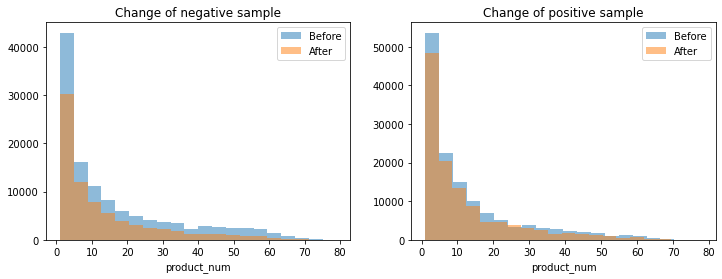

In [ ]:
def show_stage1_plot(p):
    pred = np.where(lgbm.predict_proba(X_val)[:, 1] > p, 1, 0)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    before_index = np.where(Y_val.values == 0)
    plt.hist(X_val["product_num"].values[before_index], alpha = 0.5, label = "Before", bins = 20)

    after_index = np.where((pred == 1) & (Y_val.values == 0))
    plt.hist(X_val["product_num"].values[after_index], alpha = 0.5, label = "After", bins = 20)
    plt.xlabel("product_num")
    plt.title("Change of negative sample")
    plt.legend()

    plt.subplot(1, 2, 2)
    before_index = np.where(Y_val.values == 1)
    plt.hist(X_val["product_num"].values[before_index], alpha = 0.5, label = "Before", bins = 20)

    after_index = np.where((pred == 1) & (Y_val.values == 1))
    plt.hist(X_val["product_num"].values[after_index], alpha = 0.5, label = "After", bins = 20)
    plt.xlabel("product_num")
    plt.title("Change of positive sample")
    plt.legend()

    plt.show()

show_stage1_plot(0.4)

In [ ]:
def stage1_result(X_train, X_val, X_test, p):
    X_train = X_train.copy()
    X_val = X_val.copy()
    X_test = X_test.copy()

    X_train["Prediction"] = np.where(lgbm.predict_proba(X_train)[:, 1] > p, 1, 0)
    X_val["Prediction"] = np.where(lgbm.predict_proba(X_val)[:, 1] > p, 1, 0)
    X_test["Prediction"] = np.where(lgbm.predict_proba(X_test)[:, 1] > p, 1, 0)

    remove_train = X_train[X_train["Prediction"] == 0].index
    remove_val = X_val[X_val["Prediction"] == 0].index
    remove_test = X_test[X_test["Prediction"] == 0].index

    print("제거된 train 표본 비율: ", len(remove_train) / X_train.shape[0])
    print("제거된 validation 표본 비율: ", len(remove_val) / X_val.shape[0])
    print("제거된 test 표본 비율: ", len(remove_test) / X_test.shape[0])

    return set(remove_train), set(remove_val), set(remove_test)

remove_train, remove_val, remove_test = stage1_result(X_train, X_val, X_test, 0.4)

제거된 train 표본 비율:  0.26192495274740113
제거된 validation 표본 비율:  0.23573273054070812
제거된 test 표본 비율:  0.26315635878515


#### **2-2 Stage 2. 대출 상품별 유저의 신청 여부 예측**


In [ ]:
train_stage2 = train[~train["application_id"].isin(remove_train)]
val_stage2 = validation[~validation["application_id"].isin(remove_val)]
test_stage2 = test[~test["application_id"].isin(remove_test)]

#### (train, val)

In [ ]:
#user spec data 복원
train_clustering = train_stage2.loc[:, :"trend"]
val_clustering = val_stage2.loc[:, :"trend"]

#중복 제거
train_clustering = train_clustering[~train_clustering.duplicated()]
val_clustering = val_clustering[~val_clustering.duplicated()]

#### (test)

In [ ]:
#user spec data 복원
test_clustering = test_stage2.loc[:, :"trend"]

#중복 제거
test_clustering = test_clustering[~test_clustering.duplicated()]

In [ ]:
"""시드 고정"""

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

SEED = 3242
seed_everything(seed = SEED)

In [ ]:
#autoencoder

class AEnet(nn.Module):
    def __init__(self, input_size, drop_rate, hidden_unit_sizes):
        super(AEnet, self).__init__()
        self.input_size = input_size
        self.hidden_unit_sizes = hidden_unit_sizes

        encoder = [nn.Linear(input_size, hidden_unit_sizes[0]),
                   nn.BatchNorm1d(hidden_unit_sizes[0]),
                   nn.Dropout(drop_rate),
                   nn.ReLU()]

        decoder = [nn.Linear(hidden_unit_sizes[0], input_size)]

        for i in range(len(hidden_unit_sizes)-1):
            encoder.append(nn.Linear(hidden_unit_sizes[i], hidden_unit_sizes[i+1]))
            encoder.append(nn.BatchNorm1d(hidden_unit_sizes[i+1]))
            encoder.append(nn.Dropout(drop_rate))
            encoder.append(nn.ReLU())

            decoder.insert(0, nn.ReLU())
            decoder.insert(0, nn.Dropout(drop_rate))
            decoder.insert(0, nn.BatchNorm1d(hidden_unit_sizes[i]))
            decoder.insert(0, nn.Linear(hidden_unit_sizes[i+1], hidden_unit_sizes[i]))


        self.encoder = nn.Sequential(
            *encoder
        )

        self.decoder = nn.Sequential(
            *decoder
        )

    def forward(self,x):
        latent = self.encoder(x)
        out = self.decoder(latent)
        return latent, out

In [ ]:
"""scaling"""

num_col = ['credit_score','yearly_income','desired_amount','birth_year','existing_loan_cnt','existing_loan_amt','trend']

X_train_num = train_clustering[num_col]
X_train_least = train_clustering.drop(num_col,axis=1)

X_val_num = val_clustering[num_col]
X_val_least = val_clustering.drop(num_col,axis=1)

X_test_num = test_clustering[num_col]
X_test_least = test_clustering.drop(num_col,axis=1)


scaler = StandardScaler()
X_scaled   = scaler.fit(X_train_num)

trn_s = X_scaled.transform(X_train_num)
val_s = X_scaled.transform(X_val_num)
tes_s = X_scaled.transform(X_test_num)

trn_df = pd.DataFrame(trn_s, columns = num_col, index = X_train_num.index)
scaled_train = pd.concat([trn_df, X_train_least],1)

val_df = pd.DataFrame(val_s, columns = num_col, index = X_val_num.index)
scaled_val = pd.concat([val_df, X_val_least],1)

tes_df = pd.DataFrame(tes_s, columns = num_col, index = X_test_num.index)
scaled_test = pd.concat([tes_df, X_test_least],1)

#### 훈련루프
 - 저장된 파라미터를 그냥 사용할 경우 주석 처리된 코드는 무시
 - 파라미터를 다시 찾고 싶을 경우 주석을 풀어주고 train 함수의 search 인자를 True로 변경하고 실행

In [ ]:
# def param(): # optuna로 찾은 파라미터 삽입:
#     USER_NAME = 'JE'
#     SEED      = 3242
#     batch_size= 512
#     epoch     = 388
#     lr        = 0.00018089695056588547
#     drop_rate = 0.5266754771377539

#     hidden = {
#         'hidden' : [296, 149, 5],
#      }

#     return hidden, SEED, batch_size, lr, epoch, drop_rate

# def make_stage2_tensorset(dataset):


#     X_total = pd.get_dummies(dataset.drop(["application_id","user_id",
#                                           "insert_time"], axis = 1))




#     return X_total



# def train(trial, search = False):  #optuna 사용 시 search = True로 변경
#     hidden, SEED, batch_size, lr, epoch, drop_rate = param()

#     # search parameters
#     if search == True:
#         for idx, i in enumerate(hidden):
#             num_layers = trial.suggest_int(f'num_layer_{idx}', 3, 3) # layer 수

#             for i in range(num_layers):
#                 if i == num_layers-1:
#                     hidden['hidden'].append(trial.suggest_int(f'h{i+1}', 3, 5)) # 마지막 layer node 수
#                     break;
#                 hidden['hidden'].append(trial.suggest_int(f'h{i+1}', 34, 300)) # node 수


#         epoch     = trial.suggest_int('epoch', 100, 500)
#         lr        = trial.suggest_loguniform('learning_rate', 1e-4, 1e-2)
#         drop_rate = trial.suggest_uniform('drop_rate', 0.5, 0.6)

#     print(hidden)
#     print('learning_rate : ', lr, "\nepoch : ", epoch, "\ndrop_rate : ", drop_rate)

#     results_loss = {
#     'epoch'              : [],
#     'loss_val'         : [],
#     'loss_val_AE'      : [],
#     'loss_val_APPLY'  : []
#     }


#     df_X  = make_stage2_tensorset(scaled_train)
#     df_X_val  = make_stage2_tensorset(scaled_val)

#     trn_x  = torch.FloatTensor(np.array(df_X)).to(device)
#     val_x  = torch.FloatTensor(np.array(df_X_val)).to(device)


# #     train = TensorDataset(trn_x)
# #     val = TensorDataset(val_x)

#     nfeat = trn_x.size(1)

#     train_load  = torch.utils.data.DataLoader(dataset= trn_x, batch_size=batch_size, shuffle=True, drop_last=False)
#     val_load   = torch.utils.data.DataLoader(dataset= val_x, batch_size=batch_size, shuffle=False, drop_last=False)



#     # 모델 정의
#     model = AEnet(nfeat, drop_rate, hidden['hidden']).to(device)

#     print(model)

#     loss_func_reconstruction = nn.MSELoss() #RECONSTRUCTION LOSS

#     optimizer = optim.Adam(model.parameters(), lr=lr)

#     for i in range(1, epoch+1):

#         train_loss = {
#         'AutoEncoder' : []

#         }

#         valid_loss = {
#         'AutoEncoder' : []

#         }

#         start = time.time()
#         model.train()
#         for j, X  in enumerate(train_load):

#             optimizer.zero_grad()
#             latent, outputs = model.forward(X)

#             loss_AE = loss_func_reconstruction(outputs, X)

#             loss_AE.backward()
#             optimizer.step()

#             train_loss['AutoEncoder'].append(loss_AE.item())


#         tr_mean_auto = np.array(train_loss['AutoEncoder']).mean()


#         train_loss_y = tr_mean_auto
#         model.eval()
#         with torch.no_grad():
#             for j, X_t in enumerate(val_load):

#                 latent_val, outputs_val = model.forward(X_t)


#                 loss_val_AE = loss_func_reconstruction(outputs_val, X_t)

#                 valid_loss['AutoEncoder'].append(loss_val_AE.item())



#         va_mean_auto = np.array(valid_loss['AutoEncoder']).mean()

#         valid_loss_y = va_mean_auto

#         end = time.time()

#         if i % 1 == 0:
#             print(f'epoch {i}  time: {end - start:.2f}sec')
#             print(f'             loss_train: {train_loss_y:.3f}')
#             print(f'             loss_valid: {valid_loss_y:.4f}')


#     print('best epoch :', results_loss['epoch'], 'loss_val :', results_loss['loss_val'], 'loss_val_AE :', results_loss['loss_val_AE'])

#     print('Train End-------------------------\n')

#     """모델 저장"""

#     torch.save(
#         {

#             "model_state_dict": model.state_dict(),
#             "optimizer_state_dict": optimizer.state_dict(),
#         },
#         f(path + "AE_model_param.pt"),
#     )

#     return np.round(results_loss['loss_val'], 4)

In [ ]:
# """파라미터를 다시 찾을때
#     9번 code의 n_trials 값을 입력하고 실행

# """

# device            = torch.device('cuda:3') #use gpu

# # Set parameters

# study = optuna.create_study(sampler=optuna.samplers.TPESampler(), direction="minimize")
# study.optimize(train, n_trials = ????)

# pruned_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
# complete_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]


# print("Study statistics: ")
# print("  Number of finished trials: ", len(study.trials))
# print("  Number of pruned trials: ", len(pruned_trials))
# print("  Number of complete trials: ", len(complete_trials))

# print("Best trial:")
# trial = study.best_trial

# print("  Value: ", trial.value)

# print("  Params: ")
# for key, value in trial.params.items():
#     print("    {}: {}".format(key, value))

In [ ]:
def make_stage2_tensorset(dataset):

    X_total = pd.get_dummies(dataset.drop(["application_id","user_id",
                                          "insert_time"], axis = 1))

    return X_total

In [ ]:
"""dataframe -> torch tensor"""

device            = torch.device('cuda:3') # use gpu

df_X  = make_stage2_tensorset(scaled_train)
df_X_val  = make_stage2_tensorset(scaled_val)
df_X_test  = make_stage2_tensorset(scaled_test)

trn_x  = torch.FloatTensor(np.array(df_X)).to(device)
val_x  = torch.FloatTensor(np.array(df_X_val)).to(device)
test_x  = torch.FloatTensor(np.array(df_X_test)).to(device)

nfeat = trn_x.size(1) #input size

"""data loader"""

full_train_load  = torch.utils.data.DataLoader(dataset= trn_x, batch_size=trn_x.size(0), shuffle=False, drop_last=False)
full_val_load   = torch.utils.data.DataLoader(dataset= val_x, batch_size=val_x.size(0), shuffle=False, drop_last=False)
full_test_load   = torch.utils.data.DataLoader(dataset= test_x, batch_size=test_x.size(0), shuffle=False, drop_last=False)

In [ ]:
"""저장된 오토인코더 불러오기"""

lr         = 0.00018089695056588547
model      = AEnet(input_size=nfeat, drop_rate=0.5266754771377539, hidden_unit_sizes=[296, 149, 5]).to(device)
optimizer  = optim.Adam(model.parameters(), lr=lr)
checkpoint = torch.load(path + 'AE_model_param.pt')   # 모델 파라미터 불러오기

model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

In [ ]:
print(model)

AEnet(
  (encoder): Sequential(
    (0): Linear(in_features=38, out_features=296, bias=True)
    (1): BatchNorm1d(296, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Dropout(p=0.5266754771377539, inplace=False)
    (3): ReLU()
    (4): Linear(in_features=296, out_features=149, bias=True)
    (5): BatchNorm1d(149, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Dropout(p=0.5266754771377539, inplace=False)
    (7): ReLU()
    (8): Linear(in_features=149, out_features=5, bias=True)
    (9): BatchNorm1d(5, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): Dropout(p=0.5266754771377539, inplace=False)
    (11): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=5, out_features=149, bias=True)
    (1): BatchNorm1d(149, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Dropout(p=0.5266754771377539, inplace=False)
    (3): ReLU()
    (4): Linear(in_features=149, out_features=296, bias=

In [ ]:
#latent 받아오기 - train
latent_train=[]
for j, (all_X) in enumerate(full_train_load):
    train_latent, _ = model.forward(all_X)
    latent_train.append(train_latent)

latent_train_all  = torch.cat(latent_train,0)
latent_train_all  = pd.DataFrame(latent_train_all.cpu().detach().numpy())
latent_train_all = latent_train_all.rename(columns = {0:'LT1',1:'LT2', 2:'LT3', 3:'LT4',
                                  4:'LT5', 5:'LT6'})

In [ ]:
latent_train_all.head()

,LT1,LT2,LT3,LT4,LT5
0,0.000000,0.000000,0.000000,0.318723,0.436312
1,0.000000,0.211407,0.000000,0.000000,0.000000
2,0.738163,0.000000,0.000000,0.603579,0.806196
3,0.000000,0.000000,0.214958,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000


In [ ]:
# latent 받아오기 - validation
latent_val=[]
for j, (all_X) in enumerate(full_val_load):
    val_latent, _ = model.forward(all_X)
    latent_val.append(val_latent)

latent_val_all  = torch.cat(latent_val,0)
latent_val_all  = pd.DataFrame(latent_val_all.cpu().detach().numpy())
latent_val_all = latent_val_all.rename(columns = {0:'LT1',1:'LT2', 2:'LT3', 3:'LT4',
                                  4:'LT5', 5:'LT6'})

In [ ]:
latent_val_all

,LT1,LT2,LT3,LT4,LT5
0,0.000000,0.000000,3.619084,0.000000,0.000000
1,0.589062,0.000000,0.000000,0.464993,0.643068
2,0.000000,0.201838,0.000000,0.000000,0.000000
3,0.472500,0.160181,0.175975,0.000000,0.508677
4,0.245761,0.000000,0.847746,0.000000,0.000000
...,...,...,...,...,...
194741,0.000000,0.000000,1.858304,0.000000,0.000000
194742,2.114351,2.576257,0.000000,2.639502,0.000000
194743,0.272780,0.000000,0.471555,0.732381,0.193989
194744,0.000000,0.000000,1.164402,1.435528,0.000000


In [ ]:
# latent 받아오기 - test
latent_test=[]
for j, (all_X) in enumerate(full_test_load):
    ts_latent, _ = model.forward(all_X)
    latent_test.append(ts_latent)

latent_test_all  = torch.cat(latent_test,0)
latent_test_all  = pd.DataFrame(latent_test_all.cpu().detach().numpy())
latent_test_all = latent_test_all.rename(columns = {0:'LT1',1:'LT2', 2:'LT3', 3:'LT4',
                                  4:'LT5', 5:'LT6'})

In [ ]:
latent_test_all

,LT1,LT2,LT3,LT4,LT5
0,0.000000,0.000000,0.000000,0.190809,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.426936,0.000000,0.000000,0.299867,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.661125
4,0.000000,0.000000,0.000000,0.000000,0.198460
...,...,...,...,...,...
176738,0.000000,0.413486,0.431594,0.000000,0.000000
176739,0.327894,0.000000,0.383273,0.000000,0.278347
176740,0.000000,0.000000,0.669233,0.000000,0.000000
176741,0.000000,0.316172,0.391793,0.688178,0.000000


In [ ]:
# 압축된 user spec을 기존의 loan result와 결합
"""train"""

train_appidx = train_stage2.loc[:, :"trend"][~train_stage2.loc[:, :"trend"].duplicated()][['application_id']]
train_appidx.reset_index(inplace = True)
train_appidx.drop('index', axis = 1, inplace = True)

trndf = pd.concat([train_appidx,latent_train_all], axis = 1)

loan_train = train_stage2.drop(['user_id', 'insert_time', 'credit_score',
       'yearly_income', 'income_type', 'employment_type', 'houseown_type',
       'desired_amount', 'purpose', 'birth_year', 'gender',
       'existing_loan_cnt', 'existing_loan_amt', 'IsNewApply', 'day_of_week',
       'trend'], axis = 1)


loan_train = pd.merge(loan_train, trndf, how = 'left', on=['application_id'])
loan_train.head()

,application_id,bank_id,product_id,loan_limit,loan_rate,is_applied,loan_limit_order,loan_rate_order,LT1,LT2,LT3,LT4,LT5
0,2,62,200,7.176091,9.3,0.0,1.0,1.0,0.0,0.000000,0.0,0.318723,0.436312
1,2056849,59,150,7.204120,15.0,0.0,11.0,9.0,0.0,0.211407,0.0,0.000000,0.000000
2,2056849,10,149,7.556303,13.9,0.0,3.0,4.0,0.0,0.211407,0.0,0.000000,0.000000
3,2056849,30,85,7.301030,14.8,0.0,9.0,7.0,0.0,0.211407,0.0,0.000000,0.000000
4,2056849,10,65,7.556303,13.9,0.0,3.0,4.0,0.0,0.211407,0.0,0.000000,0.000000


In [ ]:
# 압축된 user spec을 기존의 loan result와 결합
"""validation"""

val_appidx = val_stage2.loc[:, :"trend"][~val_stage2.loc[:, :"trend"].duplicated()][['application_id']]
val_appidx.reset_index(inplace = True)
val_appidx.drop('index', axis = 1, inplace = True)

valdf = pd.concat([val_appidx,latent_val_all], axis = 1)

loan_val = val_stage2.drop(['user_id', 'insert_time', 'credit_score',
       'yearly_income', 'income_type', 'employment_type', 'houseown_type',
       'desired_amount', 'purpose', 'birth_year', 'gender',
       'existing_loan_cnt', 'existing_loan_amt', 'IsNewApply', 'day_of_week',
       'trend'], axis = 1)

loan_val = pd.merge(loan_val,valdf, how = 'left', on=['application_id'])

loan_val.head()

,application_id,bank_id,product_id,loan_limit,loan_rate,is_applied,loan_limit_order,loan_rate_order,LT1,LT2,LT3,LT4,LT5
0,1,59,150,7.278754,17.7,0.0,2.0,4.0,0.0,0.0,3.619084,0.0,0.0
1,1,38,223,7.278754,17.1,0.0,2.0,2.0,0.0,0.0,3.619084,0.0,0.0
2,1,50,142,7.255273,19.9,0.0,5.0,6.0,0.0,0.0,3.619084,0.0,0.0
3,1,37,206,7.505150,18.9,0.0,1.0,5.0,0.0,0.0,3.619084,0.0,0.0
4,1,38,16,7.278754,17.1,0.0,2.0,2.0,0.0,0.0,3.619084,0.0,0.0


In [ ]:
# 압축된 user spec을 기존의 loan result와 결합
"""test"""

test_appidx = test_stage2.loc[:, :"trend"][~test_stage2.loc[:, :"trend"].duplicated()][['application_id']]
test_appidx.reset_index(inplace = True)
test_appidx.drop('index', axis = 1, inplace = True)

testdf = pd.concat([test_appidx,latent_test_all], axis = 1)

loan_test = test_stage2.drop(['user_id', 'insert_time', 'credit_score',
       'yearly_income', 'income_type', 'employment_type', 'houseown_type',
       'desired_amount', 'purpose', 'birth_year', 'gender',
       'existing_loan_cnt', 'existing_loan_amt', 'IsNewApply', 'day_of_week',
       'trend'], axis = 1)

loan_test = pd.merge(loan_test,testdf, how = 'left', on=['application_id'])

loan_test.head()

,application_id,bank_id,product_id,loan_limit,loan_rate,is_applied,loan_limit_order,loan_rate_order,LT1,LT2,LT3,LT4,LT5
0,4,7,220,7.000000,11.4,NaN,2.0,1.0,0.0,0.0,0.0,0.190809,0.0
1,4,7,191,7.414973,11.4,NaN,1.0,1.0,0.0,0.0,0.0,0.190809,0.0
2,1780228,47,47,7.113943,6.8,NaN,9.0,1.0,0.0,0.0,0.0,0.000000,0.0
3,1780228,10,149,7.361728,12.4,NaN,6.0,7.0,0.0,0.0,0.0,0.000000,0.0
4,1780228,33,110,7.301030,12.6,NaN,8.0,9.0,0.0,0.0,0.0,0.000000,0.0


In [ ]:
"""scaling"""

X_num_train = loan_train.drop(['is_applied','bank_id','product_id','application_id'] , axis =1)
y = loan_train['is_applied']

X_num_val = loan_val.drop(['is_applied','bank_id','product_id','application_id'], axis =1)
y_val = loan_val['is_applied']

X_num_test = loan_test.drop(['is_applied','bank_id','product_id','application_id'], axis =1)
# y_test = loan_test['is_applied']

scaler = StandardScaler()
scaled   = scaler.fit(X_num_train)

trn = scaled.transform(X_num_train)
val = scaled.transform(X_num_val)
tes_s = scaled.transform(X_num_test)

trn_df = pd.DataFrame(trn, columns = X_num_train.columns, index = X_num_train.index)
loan_tr = pd.concat([trn_df, y],1)

val_df = pd.DataFrame(val, columns = X_num_val.columns, index = X_num_val.index)
loan_vl = pd.concat([val_df, y_val],1)

test_df = pd.DataFrame(tes_s, columns = X_num_test.columns, index = X_num_test.index)

In [ ]:
loan_tr.to_csv(path + 'train_loan.csv')
loan_vl.to_csv(path + 'val_loan.csv')
test_df.to_csv(path + 'test_loan.csv')

In [ ]:
prod_app_id_test = loan_test[['application_id','product_id']]
prod_app_id_test.to_csv(path + 'prod_app_id_test.csv')

In [ ]:
"""pycaret 전용 가상환경 추천(버전 충돌이 자주 일어남)"""

import pandas as pd
import numpy as np

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from collections import Counter

In [ ]:
## loading data ##
train = pd.read_csv(path + 'train_loan.csv', index_col = 0)
val = pd.read_csv(path + 'val_loan.csv', index_col = 0)
test = pd.read_csv(path + 'test_loan.csv', index_col = 0)

#### oversampling: SMOTE

In [ ]:
from pycaret.classification import *

s = setup(train, test_data = val, target = 'is_applied', session_id=123, fold = 2,
         fix_imbalance=True)

,Description,Value
0,session_id,123
1,Target,is_applied
2,Target Type,Binary
3,Label Encoded,"0.0: 0, 1.0: 1"
4,Original Data,"(4261238, 10)"
5,Missing Values,False
6,Numeric Features,9
7,Categorical Features,0
8,Ordinal Features,False
9,High Cardinality Features,False


In [ ]:
model = create_model('lightgbm', cross_validation = False)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.8906,0.88,0.578,0.3604,0.4439,0.3869,0.4002


In [ ]:
pred_unseen = predict_model(model)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.8906,0.8800,0.5780,0.3604,0.4439,0.3869,0.4002


In [ ]:
save_model(model, 'saved_lgbm_model_1014')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=None,
          steps=[('dtypes',
                  DataTypes_Auto_infer(categorical_features=[],
                                       display_types=True, features_todrop=[],
                                       id_columns=[],
                                       ml_usecase='classification',
                                       numerical_features=[],
                                       target='is_applied', time_features=[])),
                 ('imputer',
                  Simple_Imputer(categorical_strategy='not_available',
                                 fill_value_categorical=None,
                                 fill_value_numerical=None,
                                 numeric_s...
                  LGBMClassifier(boosting_type='gbdt', class_weight=None,
                                 colsample_bytree=1.0, importance_type='split',
                                 learning_rate=0.1, max_depth=-1,
                                 min_child_samples=20,

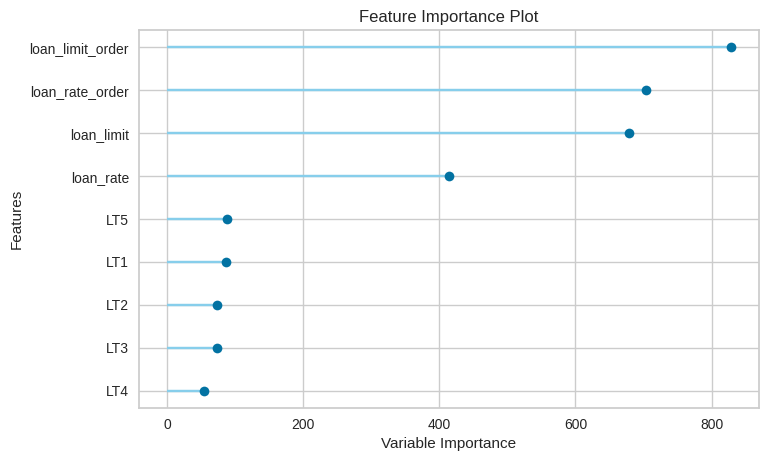

In [ ]:
plot_model(model, plot = 'feature')

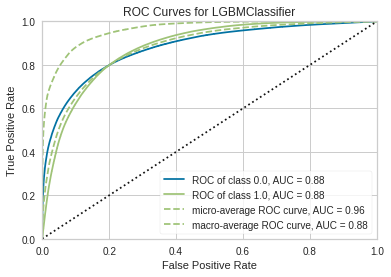

In [ ]:
plot_model(model, plot = 'auc')

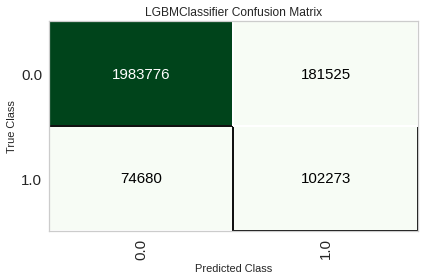

In [ ]:
plot_model(model, plot = 'confusion_matrix')

In [ ]:
"""inference"""

pred_unseen = predict_model(model, data = test)

# saved app_id, prod_id
prod_app = pd.read_csv(path + 'prod_app_id_test.csv', index_col = 0)

df = pd.concat([pred_unseen['Label'], prod_app], 1)
df.head()

,Label,application_id,product_id
0,1.0,4,220
1,1.0,4,191
2,1.0,1780228,47
3,0.0,1780228,149
4,0.0,1780228,110


In [ ]:
"""submission file"""

sub = pd.read_csv(path + '데이터분석분야_퓨처스부문_평가데이터.csv')

In [ ]:
join = pd.merge(sub, df, how = 'left', on=['application_id','product_id'])
join['Label'].isnull().sum()

1215214

In [ ]:
# 금리가 null인것 + stage 1에서 걸러진 샘플 0으로 예측
join['Label'].fillna(0.0, inplace = True)

In [ ]:
join = join.drop('is_applied', axis = 1)
submission = join.rename(columns = {'Label':'is_applied'})
submission.head()

,application_id,product_id,is_applied
0,4,220,1.0
1,4,191,1.0
2,8,29,1.0
3,8,159,0.0
4,8,85,1.0


In [ ]:
submission['is_applied'] = submission['is_applied'].astype('float') #타입 맞추기

In [ ]:
submission['is_applied'].value_counts()

0.0    3006542
1.0     248652
Name: is_applied, dtype: int64

In [ ]:
print('다수클래스 비율:', submission['is_applied'].value_counts()[0]/(3006542+248652))
print('소수클래스 비율:', submission['is_applied'].value_counts()[1]/(3006542+248652))

다수클래스 비율: 0.9236137692561488
소수클래스 비율: 0.07638623074385122


In [ ]:
submission.to_csv(path + 'submission.csv', index = False)

### **2-3 Stage 3. Clustering**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df=pd.read_csv(path + 'clustering.csv')

In [ ]:
df.head()

,application_id,user_id,insert_time,credit_score,yearly_income,income_type,employment_type,houseown_type,desired_amount,purpose,birth_year,gender,existing_loan_cnt,existing_loan_amt,IsNewApply,day_of_week,trend
0,2,28169,2022-04-13,590.0,7.633468,EARNEDINCOME,PERMANENT,OWNHOUSE,7.000000,LIVING,1981.0,1.0,12.0,8.309630,0,Wednesday,70.50726
1,2056849,59078,2022-04-13,630.0,7.556303,EARNEDINCOME,PERMANENT,RENT,7.176091,SWITCHLOAN,1991.0,1.0,4.0,7.857333,0,Wednesday,70.50726
2,1705884,646901,2022-04-13,610.0,7.633468,EARNEDINCOME,PERMANENT,RENT,6.000000,LIVING,1989.0,1.0,3.0,7.342423,0,Wednesday,70.50726
3,1384538,564962,2022-04-13,720.0,7.623249,EARNEDINCOME,PERMANENT,RENT,7.000000,LIVING,1984.0,1.0,9.0,7.819544,1,Wednesday,70.50726
4,779071,659860,2022-04-13,600.0,7.568202,EARNEDINCOME,PERMANENT,FAMILYHOUSE,6.000000,LIVING,1987.0,1.0,2.0,7.612784,0,Wednesday,70.50726


In [ ]:
new=df[['credit_score','yearly_income','income_type',
        'employment_type','houseown_type',
              'existing_loan_cnt','existing_loan_amt','IsNewApply','birth_year','desired_amount']]

In [ ]:
new.head(2)

,credit_score,yearly_income,income_type,employment_type,houseown_type,existing_loan_cnt,existing_loan_amt,IsNewApply,birth_year,desired_amount
0,590.0,7.633468,EARNEDINCOME,PERMANENT,OWNHOUSE,12.0,8.309630,0,1981.0,7.000000
1,630.0,7.556303,EARNEDINCOME,PERMANENT,RENT,4.0,7.857333,0,1991.0,7.176091


In [ ]:
"""k-prototype 은 k-means 와 k-modes 동시에 활용, 연속형과 범주형을 동시에 사용할 수 있는 클러스터링"""

from kmodes.kprototypes import KPrototypes

In [ ]:
from kmodes.kprototypes import KPrototypes
kp = KPrototypes(n_clusters=4, init='Huang', n_init=1, verbose=True, random_state = 7759)
kk=kp.fit_predict(new, categorical=[2,3,4]) # category -> 범주형 변수 컬럼 위치 인덱싱

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 162730, ncost: 2012514811.5710015
Run: 1, iteration: 2/100, moves: 138844, ncost: 1710522397.2798562
Run: 1, iteration: 3/100, moves: 107842, ncost: 1569333510.0490835
Run: 1, iteration: 4/100, moves: 73843, ncost: 1511598062.8696272
Run: 1, iteration: 5/100, moves: 8879, ncost: 1507028217.6013508
Run: 1, iteration: 6/100, moves: 9229, ncost: 1498816378.108711
Run: 1, iteration: 7/100, moves: 60964, ncost: 1462737262.239898
Run: 1, iteration: 8/100, moves: 1664, ncost: 1462698520.8862348
Run: 1, iteration: 9/100, moves: 62, ncost: 1462698465.0495896
Run: 1, iteration: 10/100, moves: 3, ncost: 1462698464.9103577
Run: 1, iteration: 11/100, moves: 0, ncost: 1462698464.9103577


In [ ]:
print(kp) #모델 파라미터

KPrototypes(cat_dissim=<function matching_dissim at 0x7ff42fa575e0>,
            gamma=9.215750297475964, init='Huang', max_iter=100, n_clusters=4,
            n_init=1, n_jobs=1,
            num_dissim=<function euclidean_dissim at 0x7ff42fa57790>,
            random_state=7759, verbose=True)


In [ ]:
new.insert(0, "Cluster", kk, True)

In [ ]:
new['Cluster']=new['Cluster']+1

In [ ]:
new['Cluster'].value_counts()

4    377836
3    282244
2    179085
1    129588
Name: Cluster, dtype: int64

In [ ]:
new.groupby('Cluster')['credit_score','yearly_income',
              'existing_loan_cnt','existing_loan_amt','IsNewApply','birth_year','desired_amount'].mean()

,credit_score,yearly_income,existing_loan_cnt,existing_loan_amt,IsNewApply,birth_year,desired_amount
Cluster,,,,,,,
1,891.464455,7.595231,2.392436,6.073081,0.046517,1982.350117,7.495701
2,548.289107,7.516243,4.911701,6.976439,0.086490,1983.718095,6.998351
3,726.109397,7.502530,2.724030,5.430086,0.055580,1982.780059,7.257615
4,627.975769,7.507984,4.613361,6.933599,0.072558,1982.515978,7.118897


In [ ]:
new1=new[new['Cluster']==1]
new2=new[new['Cluster']==2]
new3=new[new['Cluster']==3]
new4=new[new['Cluster']==4]

In [ ]:
new1['income_type'].value_counts()

EARNEDINCOME       89349
PRIVATEBUSINESS    15543
OTHERINCOME        11384
FREELANCER          6959
EARNEDINCOME2       3658
PRACTITIONER        2695
Name: income_type, dtype: int64

In [ ]:
new2['income_type'].value_counts()

EARNEDINCOME       141326
EARNEDINCOME2       13829
OTHERINCOME          9277
FREELANCER           6588
PRIVATEBUSINESS      5291
PRACTITIONER         2774
Name: income_type, dtype: int64

In [ ]:
new3['income_type'].value_counts()

EARNEDINCOME       175183
OTHERINCOME         35017
PRIVATEBUSINESS     31416
FREELANCER          20125
EARNEDINCOME2       15722
PRACTITIONER         4781
Name: income_type, dtype: int64

In [ ]:
new4['income_type'].value_counts()

EARNEDINCOME       255042
OTHERINCOME         37217
EARNEDINCOME2       28155
PRIVATEBUSINESS     27452
FREELANCER          24389
PRACTITIONER         5581
Name: income_type, dtype: int64

In [ ]:
new1['employment_type'].value_counts()

PERMANENT         93854
EMPLOYMENT_ETC    26542
CONTRACT           8212
DAYJOB              980
Name: employment_type, dtype: int64

In [ ]:
new2['employment_type'].value_counts()

PERMANENT         136499
EMPLOYMENT_ETC     20882
CONTRACT           18377
DAYJOB              3327
Name: employment_type, dtype: int64

In [ ]:
new3['employment_type'].value_counts()

PERMANENT         182887
EMPLOYMENT_ETC     72353
CONTRACT           23150
DAYJOB              3854
Name: employment_type, dtype: int64

In [ ]:
new4['employment_type'].value_counts()

PERMANENT         257028
EMPLOYMENT_ETC     78979
CONTRACT           35206
DAYJOB              6623
Name: employment_type, dtype: int64

In [ ]:
new1['houseown_type'].value_counts()

RENT           54865
OWNHOUSE       47174
FAMILYHOUSE    27487
SPOUSE            62
Name: houseown_type, dtype: int64

In [ ]:
new2['houseown_type'].value_counts()

RENT           82944
FAMILYHOUSE    66302
OWNHOUSE       29649
SPOUSE           190
Name: houseown_type, dtype: int64

In [ ]:
new3['houseown_type'].value_counts()

RENT           128223
FAMILYHOUSE     83615
OWNHOUSE        69899
SPOUSE            507
Name: houseown_type, dtype: int64

In [ ]:
new4['houseown_type'].value_counts()

RENT           172983
FAMILYHOUSE    126123
OWNHOUSE        78358
SPOUSE            372
Name: houseown_type, dtype: int64

In [ ]:
new1['IsNewApply'].value_counts()

0    123560
1      6028
Name: IsNewApply, dtype: int64

In [ ]:
new2['IsNewApply'].value_counts()

0    163596
1     15489
Name: IsNewApply, dtype: int64

In [ ]:
new3['IsNewApply'].value_counts()

0    266557
1     15687
Name: IsNewApply, dtype: int64

In [ ]:
new4['IsNewApply'].value_counts()

0    350421
1     27415
Name: IsNewApply, dtype: int64

(400.0, 1000.0)

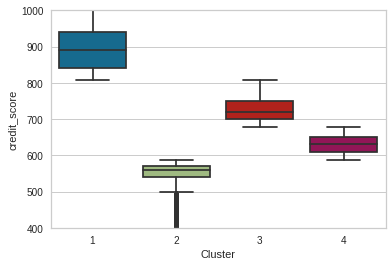

In [ ]:
#시각화
sns.boxplot(y='credit_score',x='Cluster',data=new)
plt.ylim(400,1000)

(7.2, 7.8)

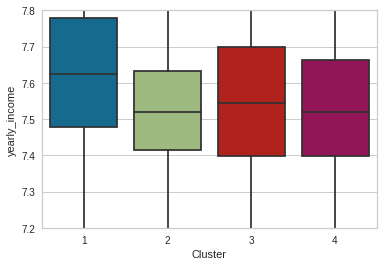

In [ ]:
sns.boxplot(data=new,y='yearly_income',x='Cluster')
plt.ylim(7.2,7.8)

<AxesSubplot:xlabel='income_type', ylabel='count'>

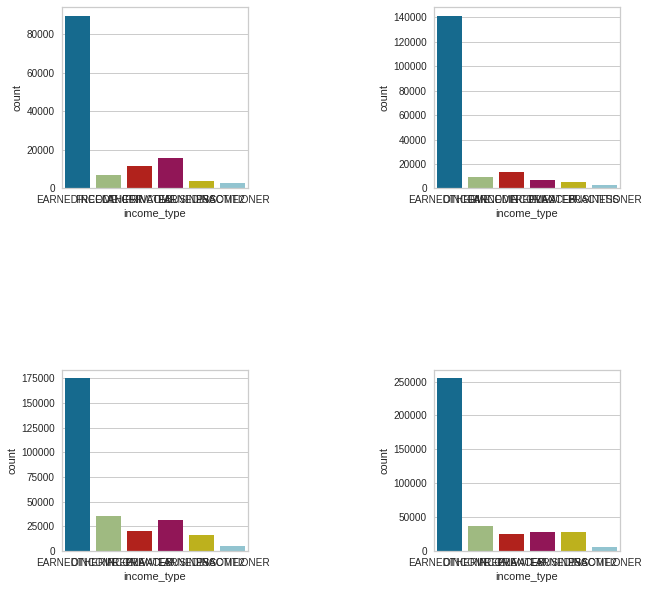

In [ ]:
fig, ax = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(10, 10))

plt.subplots_adjust(wspace=1, hspace=1)

sns.countplot(data=new1,x='income_type',ax=ax[0][0])
sns.countplot(data=new2,x='income_type',ax=ax[0][1])
sns.countplot(data=new3,x='income_type',ax=ax[1][0])
sns.countplot(data=new4,x='income_type',ax=ax[1][1])

<AxesSubplot:xlabel='Cluster', ylabel='count'>

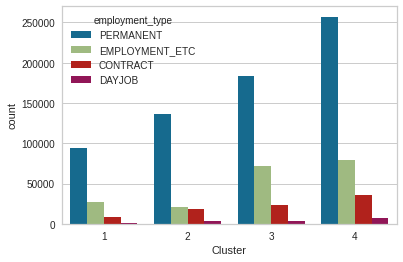

In [ ]:
sns.countplot(data=new,x='Cluster',hue='employment_type')

<AxesSubplot:xlabel='Cluster', ylabel='count'>

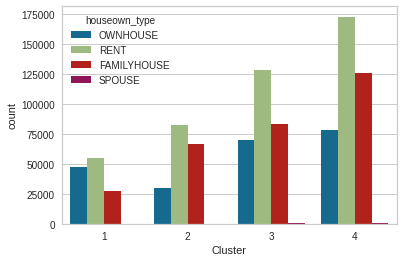

In [ ]:
sns.countplot(data=new, x='Cluster',hue='houseown_type')

(0.0, 20.0)

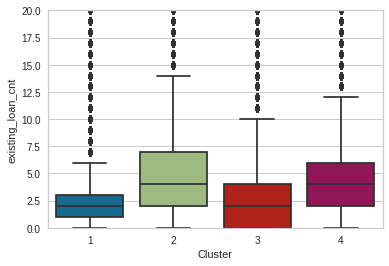

In [ ]:
sns.boxplot(data=new, x='Cluster',y= 'existing_loan_cnt')
plt.ylim(0,20)

<AxesSubplot:xlabel='Cluster', ylabel='existing_loan_amt'>

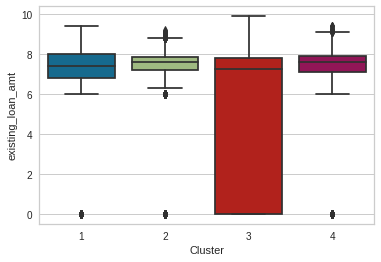

In [ ]:
sns.boxplot(data=new,y= 'existing_loan_amt',x='Cluster')

In [ ]:
new.groupby('Cluster')['IsNewApply'].value_counts()

Cluster  IsNewApply
1        0             123560
         1               6028
2        0             163596
         1              15489
3        0             266557
         1              15687
4        0             350421
         1              27415
Name: IsNewApply, dtype: int64

<AxesSubplot:xlabel='Cluster', ylabel='birth_year'>

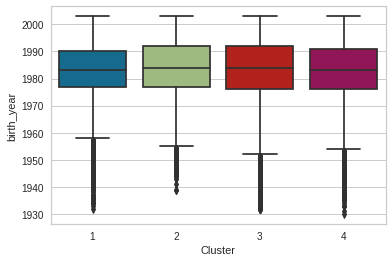

In [ ]:
sns.boxplot(data=new,y='birth_year',x='Cluster')

<AxesSubplot:xlabel='Cluster', ylabel='desired_amount'>

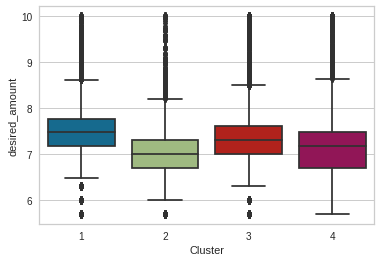

In [ ]:
sns.boxplot(data=new,y= 'desired_amount',x='Cluster')